In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import geopandas

In [3]:
crossfire_data_path = r"..\data\raw\fogo_cruzado\fc_api_occurrences_with_victims_2026-04-30T13_07_37.000Z.csv"
limite_favelas_path = r"..\data\raw\Limite_Favelas_2022.geojson"
crossfire_df = pd.read_csv(crossfire_data_path)
limites_gdf = geopandas.read_file(limite_favelas_path)

In [4]:
limites_gdf = limites_gdf["geometry"]

In [5]:
crossfire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28262 entries, 0 to 28261
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    28262 non-null  int64  
 1   address               28262 non-null  str    
 2   region                28262 non-null  str    
 3   state                 28262 non-null  str    
 4   city                  28262 non-null  str    
 5   neighborhood          28262 non-null  str    
 6   sub_neighborhood      161 non-null    str    
 7   locality              19927 non-null  str    
 8   latitude              28262 non-null  float64
 9   longitude             28262 non-null  float64
 10  data                  28262 non-null  str    
 11  police_action         28262 non-null  bool   
 12  agent_presence        28262 non-null  bool   
 13  police_unit           7938 non-null   str    
 14  main_reason           28262 non-null  str    
 15  complementary_reason  0 non-nu

In [6]:
crossfire_df.columns

Index(['id', 'address', 'region', 'state', 'city', 'neighborhood',
       'sub_neighborhood', 'locality', 'latitude', 'longitude', 'data',
       'police_action', 'agent_presence', 'police_unit', 'main_reason',
       'complementary_reason', 'clippings', 'massacre', 'civilians_dead',
       'civilians_wounded', 'agents_dead', 'agents_wounded', 'men_dead',
       'men_wounded', 'women_dead', 'women_wounded', 'kids_dead',
       'kids_wounded', 'teenagers_dead', 'teenagers_wounded', 'elderly_dead',
       'elderly_wounded'],
      dtype='str')

In [7]:
crossfire_df['neighborhood'].value_counts()

neighborhood
VILA KENNEDY          1558
COMPLEXO DO ALEMAO    1108
PRACA SECA            1089
CIDADE DE DEUS        1071
TIJUCA                 878
                      ... 
MONERO                   3
JOA                      2
CAMPO DOS AFONSOS        1
RIBEIRA                  1
GRUMARI                  1
Name: count, Length: 162, dtype: int64

In [8]:
crossfire_df['neighborhood'].value_counts().head(10)

neighborhood
VILA KENNEDY           1558
COMPLEXO DO ALEMAO     1108
PRACA SECA             1089
CIDADE DE DEUS         1071
TIJUCA                  878
MARE                    814
BANGU                   750
VICENTE DE CARVALHO     581
PENHA                   563
MADUREIRA               556
Name: count, dtype: int64

In [9]:
crossfire_df['civilians_dead'].value_counts()

civilians_dead
0      25281
1       2281
2        451
3        143
4         55
5         17
6         16
7          5
8          4
10         2
12         1
13         1
27         1
9          1
23         1
16         1
117        1
Name: count, dtype: int64

In [10]:
crossfire_df[["civilians_dead","civilians_wounded"]].isna().sum()

civilians_dead       0
civilians_wounded    0
dtype: int64

In [11]:
crossfire_df['civilians_wounded'].value_counts()

civilians_wounded
0     24977
1      2397
2       620
3       180
4        47
5        18
6        14
8         4
9         2
11        1
10        1
7         1
Name: count, dtype: int64

In [12]:
crossfire_df.drop(["address","region","state","city","sub_neighborhood",'complementary_reason', "police_unit", "clippings",'agents_dead', 'agents_wounded',
       'men_dead', 'men_wounded', 'women_dead', 'women_wounded', 'kids_dead',
       'kids_wounded', 'teenagers_dead', 'teenagers_wounded', 'elderly_dead',
       'elderly_wounded'], axis=1, inplace=True)
crossfire_df.head()

,id,neighborhood,locality,latitude,longitude,data,police_action,agent_presence,main_reason,massacre,civilians_dead,civilians_wounded
0,5318,COMPLEXO DO ALEMAO,NOVA BRASILIA (COMPLEXO DO ALEMAO),-22.866065,-43.272438,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0
1,5325,CIDADE DE DEUS,CIDADE DE DEUS,-22.948170,-43.362671,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0
2,69,SAMPAIO,MORRO DOS MACACOS,-22.901310,-43.263218,"04/07/2016, 21:40:00",False,False,Não identificado,False,0,0
3,16,SANTA CRUZ,COMPLEXO DO RODO,-22.919651,-43.684387,"05/07/2016, 03:02:00",True,True,Operação policial,False,0,0
4,229,ACARI,NaN,-22.825531,-43.344460,"05/07/2016, 08:50:00",True,True,Operação policial,False,0,0


In [13]:
dt = pd.to_datetime(crossfire_df["data"], dayfirst=True, errors="coerce")
crossfire_df["data_timestamp"] = dt.dt.normalize()
crossfire_df["hora_timestamp"] = dt.dt.time
crossfire_df["hora"] = pd.to_datetime(
    crossfire_df["hora_timestamp"].astype(str),
    errors="coerce"
).dt.hour

crossfire_df.head()

C:\Users\Pichau\AppData\Local\Temp\ipykernel_24092\4082304282.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crossfire_df["hora"] = pd.to_datetime(


,id,neighborhood,locality,latitude,longitude,data,police_action,agent_presence,main_reason,massacre,civilians_dead,civilians_wounded,data_timestamp,hora_timestamp,hora
0,5318,COMPLEXO DO ALEMAO,NOVA BRASILIA (COMPLEXO DO ALEMAO),-22.866065,-43.272438,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0,2016-07-04,21:00:00,21
1,5325,CIDADE DE DEUS,CIDADE DE DEUS,-22.948170,-43.362671,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0,2016-07-04,21:00:00,21
2,69,SAMPAIO,MORRO DOS MACACOS,-22.901310,-43.263218,"04/07/2016, 21:40:00",False,False,Não identificado,False,0,0,2016-07-04,21:40:00,21
3,16,SANTA CRUZ,COMPLEXO DO RODO,-22.919651,-43.684387,"05/07/2016, 03:02:00",True,True,Operação policial,False,0,0,2016-07-05,03:02:00,3
4,229,ACARI,NaN,-22.825531,-43.344460,"05/07/2016, 08:50:00",True,True,Operação policial,False,0,0,2016-07-05,08:50:00,8


In [14]:
crossfire_df.groupby(crossfire_df["data_timestamp"].dt.year).size()

data_timestamp
2016    1604
2017    3565
2018    5700
2019    4344
2020    2724
2021    2503
2022    2176
2023    1974
2024    1690
2025    1570
2026     412
dtype: int64

In [15]:
crossfire_df["main_reason"].unique()

<StringArray>
[            'Ação policial',          'Não identificado',
         'Operação policial',           'Tentativa/Roubo',
       'Homicidio/Tentativa',                   'Disputa',
              'Tiros a esmo',            'Ataque a civis',
 'Tentativa/Roubo de cargas',                     'Briga',
 'Sequestro/Cárcere Privado',                  'Arrastão',
   'Tentativa/Roubo a banco',         'Disparo Acidental',
                   'Tortura',                  'Suicídio',
                     'Outro']
Length: 17, dtype: str

In [16]:
crossfire_df.describe()

,id,latitude,longitude,civilians_dead,civilians_wounded,data_timestamp,hora
count,28262.000000,28262.000000,28262.000000,28262.000000,28262.000000,28262,28262.000000
mean,32726.387021,-22.887871,-43.328051,0.152749,0.163364,2020-05-18 22:10:21.102540,12.138773
min,16.000000,-23.062066,-43.718054,0.000000,0.000000,2016-07-04 00:00:00,0.000000
25%,14130.500000,-22.916930,-43.369720,0.000000,0.000000,2018-05-10 00:00:00,6.000000
50%,30236.500000,-22.883636,-43.315278,0.000000,0.000000,2019-08-28 00:00:00,13.000000
75%,49684.750000,-22.857810,-43.254520,0.000000,0.000000,2022-05-15 00:00:00,18.000000
max,77086.000000,-22.774151,-43.152561,117.000000,11.000000,2026-04-30 00:00:00,23.000000
std,21664.550249,0.045617,0.100112,0.900003,0.536577,NaN,6.702940


In [17]:
crossfire_df.isnull().sum()

id                      0
neighborhood            0
locality             8335
latitude                0
longitude               0
data                    0
police_action           0
agent_presence          0
main_reason             0
massacre                0
civilians_dead          0
civilians_wounded       0
data_timestamp          0
hora_timestamp          0
hora                    0
dtype: int64

In [18]:
crossfire_df.groupby("main_reason").size()

main_reason
Arrastão                        53
Ataque a civis                  92
Ação policial                 4332
Briga                          169
Disparo Acidental               13
Disputa                        994
Homicidio/Tentativa            892
Não identificado             17037
Operação policial             2783
Outro                           11
Sequestro/Cárcere Privado       31
Suicídio                         4
Tentativa/Roubo               1501
Tentativa/Roubo a banco         40
Tentativa/Roubo de cargas      186
Tiros a esmo                   119
Tortura                          5
dtype: int64

In [19]:
reasons = crossfire_df["main_reason"].unique().tolist()

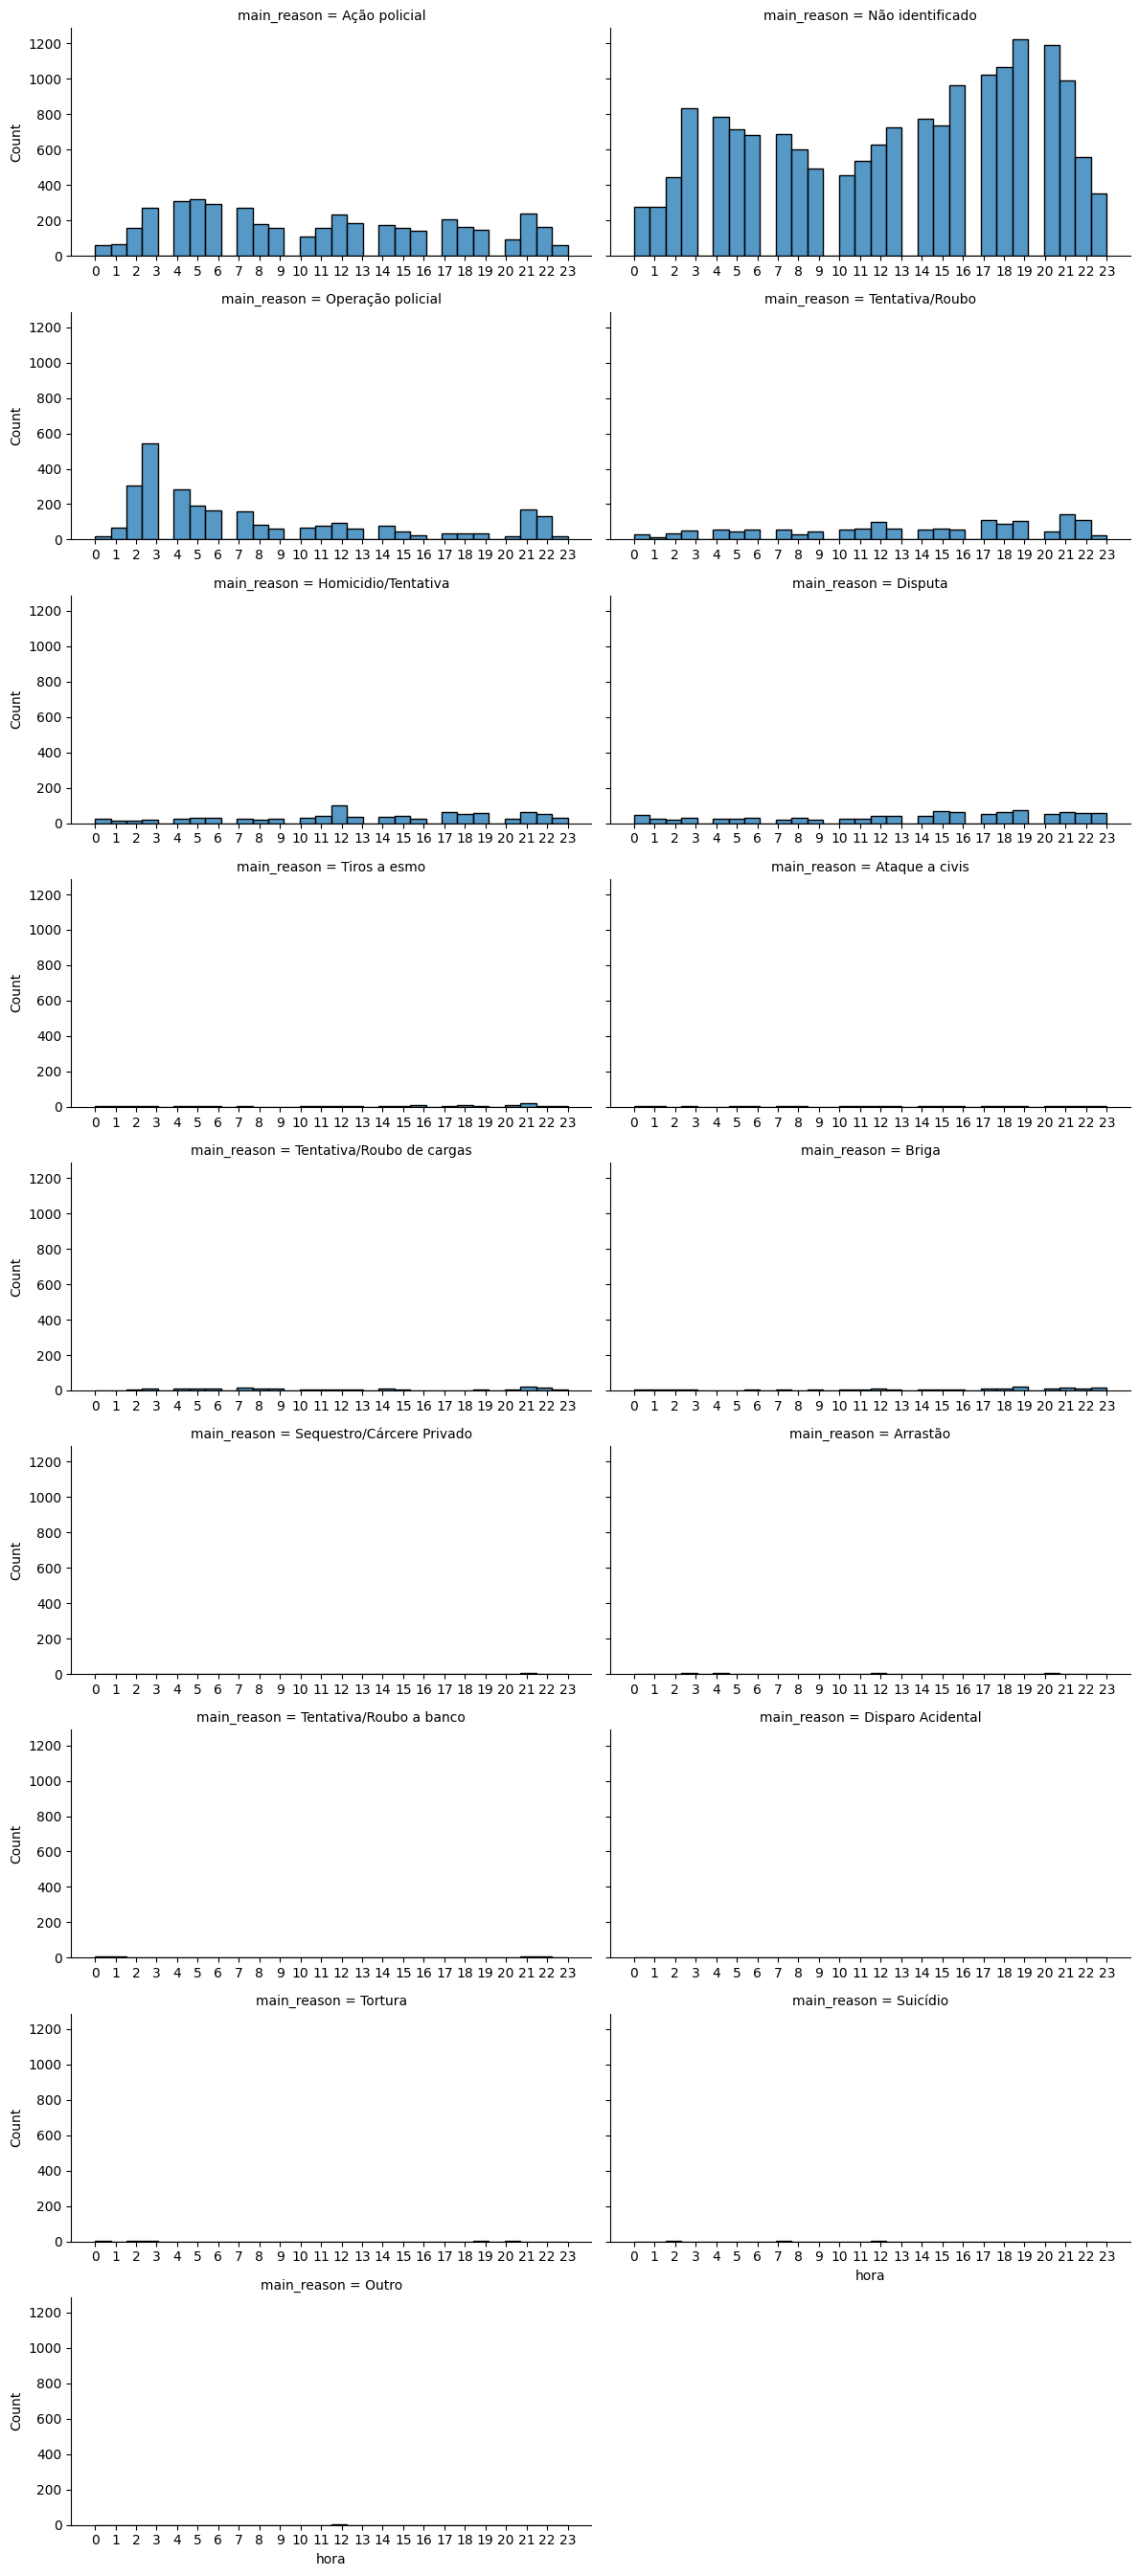

In [20]:
#sns.displot(data=crossfire_df, x=crossfire_df["hora_timestamp"].dt.hour)
#for reason in reasons:
#    current = crossfire_df[crossfire_df["main_reason"]==reason]
#    g = sns.displot(data=current, x="hora", y=f"Count: {reason}", height=4, aspect=3)

g = sns.displot(
    data=crossfire_df,
    x="hora",
    col="main_reason",
    col_wrap=2,
    height=3,
    aspect=2
)

for ax in g.axes.flatten():
    ax.set_xticks(range(0, 24))
    ax.tick_params(labelbottom=True)

plt.xticks(range(0, 24))
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

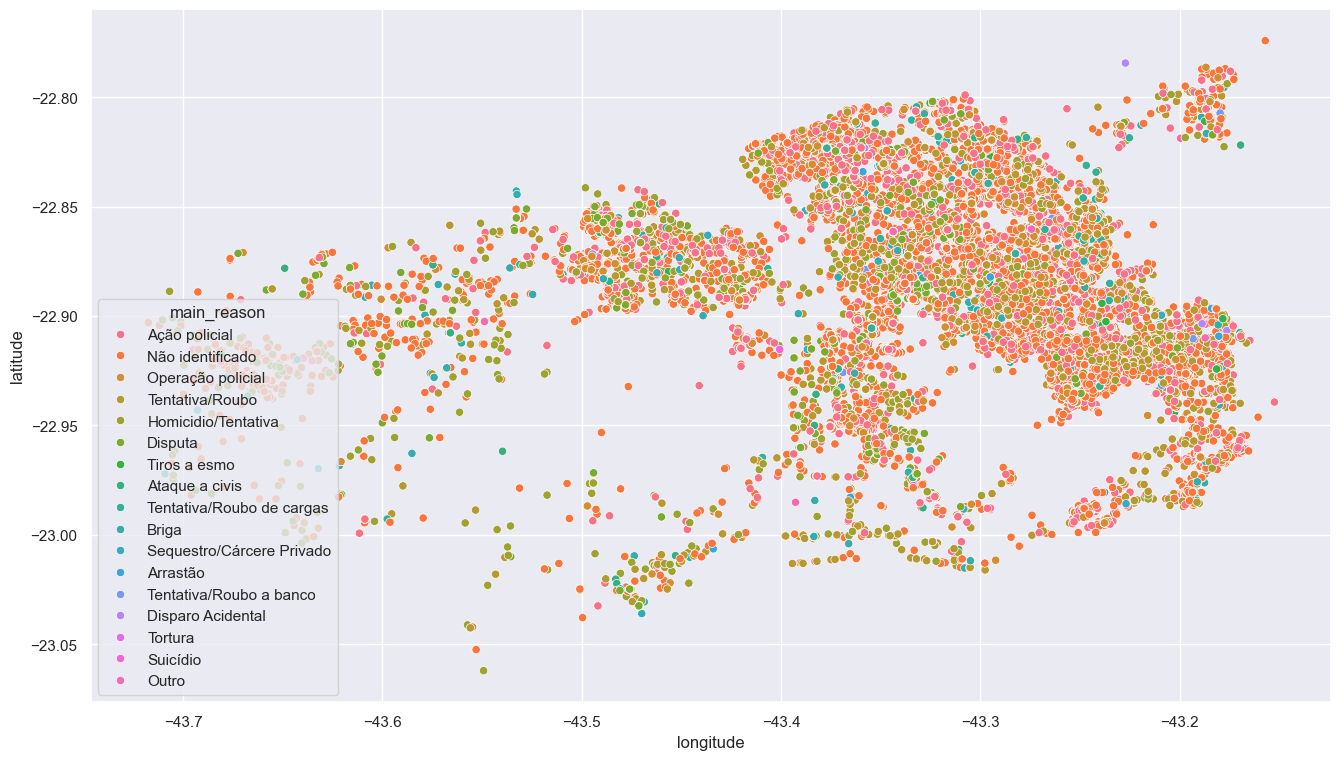

In [21]:
sns.set(rc={"figure.figsize": (16, 9)})
sns.scatterplot(x="longitude", y="latitude", hue="main_reason", data=crossfire_df)

In [22]:
mapa = folium.Map(location=[-22.9068, -43.1729], zoom_start=12)

# heat_data = crossfire_df[['latitude', 'longitude']].values.tolist()
# HeatMap(heat_data).add_to(mapa)

for ano, grupo in crossfire_df.groupby(crossfire_df["data_timestamp"].dt.year):
    heat_data = grupo[["latitude", "longitude"]].values.tolist()
    
    folium.FeatureGroup(name=str(ano)).add_child(
        HeatMap(heat_data)
    ).add_to(mapa)

folium.GeoJson(
    limites_gdf,
    name="Áreas de Favelas",
    style_function=lambda x: {
        'fillColor': 'blue',
        'color': 'blue',
        'weight': 1,
        'fillOpacity': 0.2,
    }
).add_to(mapa)

folium.LayerControl().add_to(mapa)

mapa